In [ ]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings, os, pickle, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets, aggregate_population,
    run_population_tests, run_fraction_sig_tests, run_r2_tests,
    plot_population_results, plot_r2_distributions, plot_beta_distributions,
    build_population_scatter, save_population_results,
    compare_hpf_versions, show_beta_tables, plot_target_correlations,
    plot_r2_summary,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

# Population ridge regression — spe-1

Pool single-cell ridge regression results (n=37 cells) and test whether spike waveform features systematically predict pre/post-spike LFP state.

| § | What |
|---|------|
| 1 | Load per-cell result pickles |
| 2 | Aggregate R², significance flags, and beta weights |
| 3 | Population tests: R² > 0 (primary), fraction significant (binomial), beta consistency |
| 4 | Visualisations: R² and beta heatmaps, per-cell R² distributions, beta distributions |
| 5 | Actual vs predicted scatter (pooled, z-scored within cell) |
| 6 | Save population pickle |
| 7 | HPF vs no-HPF comparison for amp/std targets |

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
PRE_WIN          = (-0.055, -0.005)
POST_WIN         = ( 0.005,  0.055)
ALPHA            = 0.05   # significance threshold (each test assessed independently)
MIN_CELLS        = 5

## Configuration

`PRE_WIN` / `POST_WIN`: time windows (s) around the spike for LFP feature extraction.  
`ALPHA`: significance threshold (default 0.05). Each target is tested independently — no correction across targets.  
`MIN_CELLS`: minimum cells required to run a population test.

**LFP targets (14 total)**  
Pre and Post absolute windows × 5 LFP features. LFP Amp and LFP Std appear as both raw and HPF (0.1 Hz zero-phase Butterworth) variants. Baseline-corrected variants are excluded — HPF handles detrending.

**Statistical approach**  
Each LFP target = a distinct scientific question, tested independently at α = 0.05. No correction across targets.

In [ ]:
# ── 1. Load — merge HPF amp/std as named targets, drop BL-corrected and Δ ──────
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

## 1. Load per-cell results

14 targets: Pre and Post windows for each of the 5 LFP features. LFP Amp and LFP Std appear twice — once using raw LFP windows and once with 0.1 Hz HPF detrending. Baseline-corrected and Δ variants are excluded (HPF handles detrending for amp/std; gamma/exponent/theta are unaffected by slow drift).

In [4]:
# ── 2. Aggregate R², significance, and betas across cells ──────────────────────
r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

## 2. Aggregate across cells

`r2_pop`   — CV R² per cell per (target × predictor set)  
`sig_pop`  — per-cell significance flags (raw permutation p < 0.05, each target independent)  
`beta_pop` — waveform beta weights (Waveform only model) per cell

In [ ]:
# ── 2b. Target correlation check ──────────────────────────────────────────────
# Are any LFP targets redundant? High Spearman ρ between per-cell R² vectors
# means the same cells succeed/fail on both targets → possible redundancy.
plot_target_correlations(r2_pop, target_names, target_labels)

## 2b. Target correlation check

Pairwise Spearman ρ between per-cell R² vectors across all 14 targets. High |ρ| means the same cells succeed/fail on both — suggesting redundancy. Informs whether any targets can be dropped without losing information.

In [ ]:
# ── 3. Population tests ───────────────────────────────────────────────────────
df_frac = run_fraction_sig_tests(
    sig_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)

sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
print(f'\nR²-significant targets (Waveform only): {sig_r2_targets}')

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

In [ ]:
# ── 3c. Beta tables — R²-significant targets ──────────────────────────────────
show_beta_tables(df_tests, sig_r2_targets, target_names, target_labels, r2_pop=r2_pop)

## 3. Population tests

**R² > 0** (`run_r2_tests`): one-sided Wilcoxon on CV R² across cells. Primary test — is the median effect size above zero? Each target assessed at α = 0.05 independently.

**Fraction significant** (`run_fraction_sig_tests`): binomial test — is the fraction of cells with p < 0.05 (per target, per cell) greater than the chance level of 5%? Each target tested independently.

**Beta consistency** (`run_population_tests`): one-sample t-test + Wilcoxon on beta weights across cells — do they have a consistent non-zero direction? Restricted to R²-significant targets; within each target, assessed across 8 waveform features.

In [ ]:
# ── 3d. R² summary — mean ± SEM per target with significance stars ─────────────
plot_r2_summary(r2_pop, df_r2, target_names, target_labels)

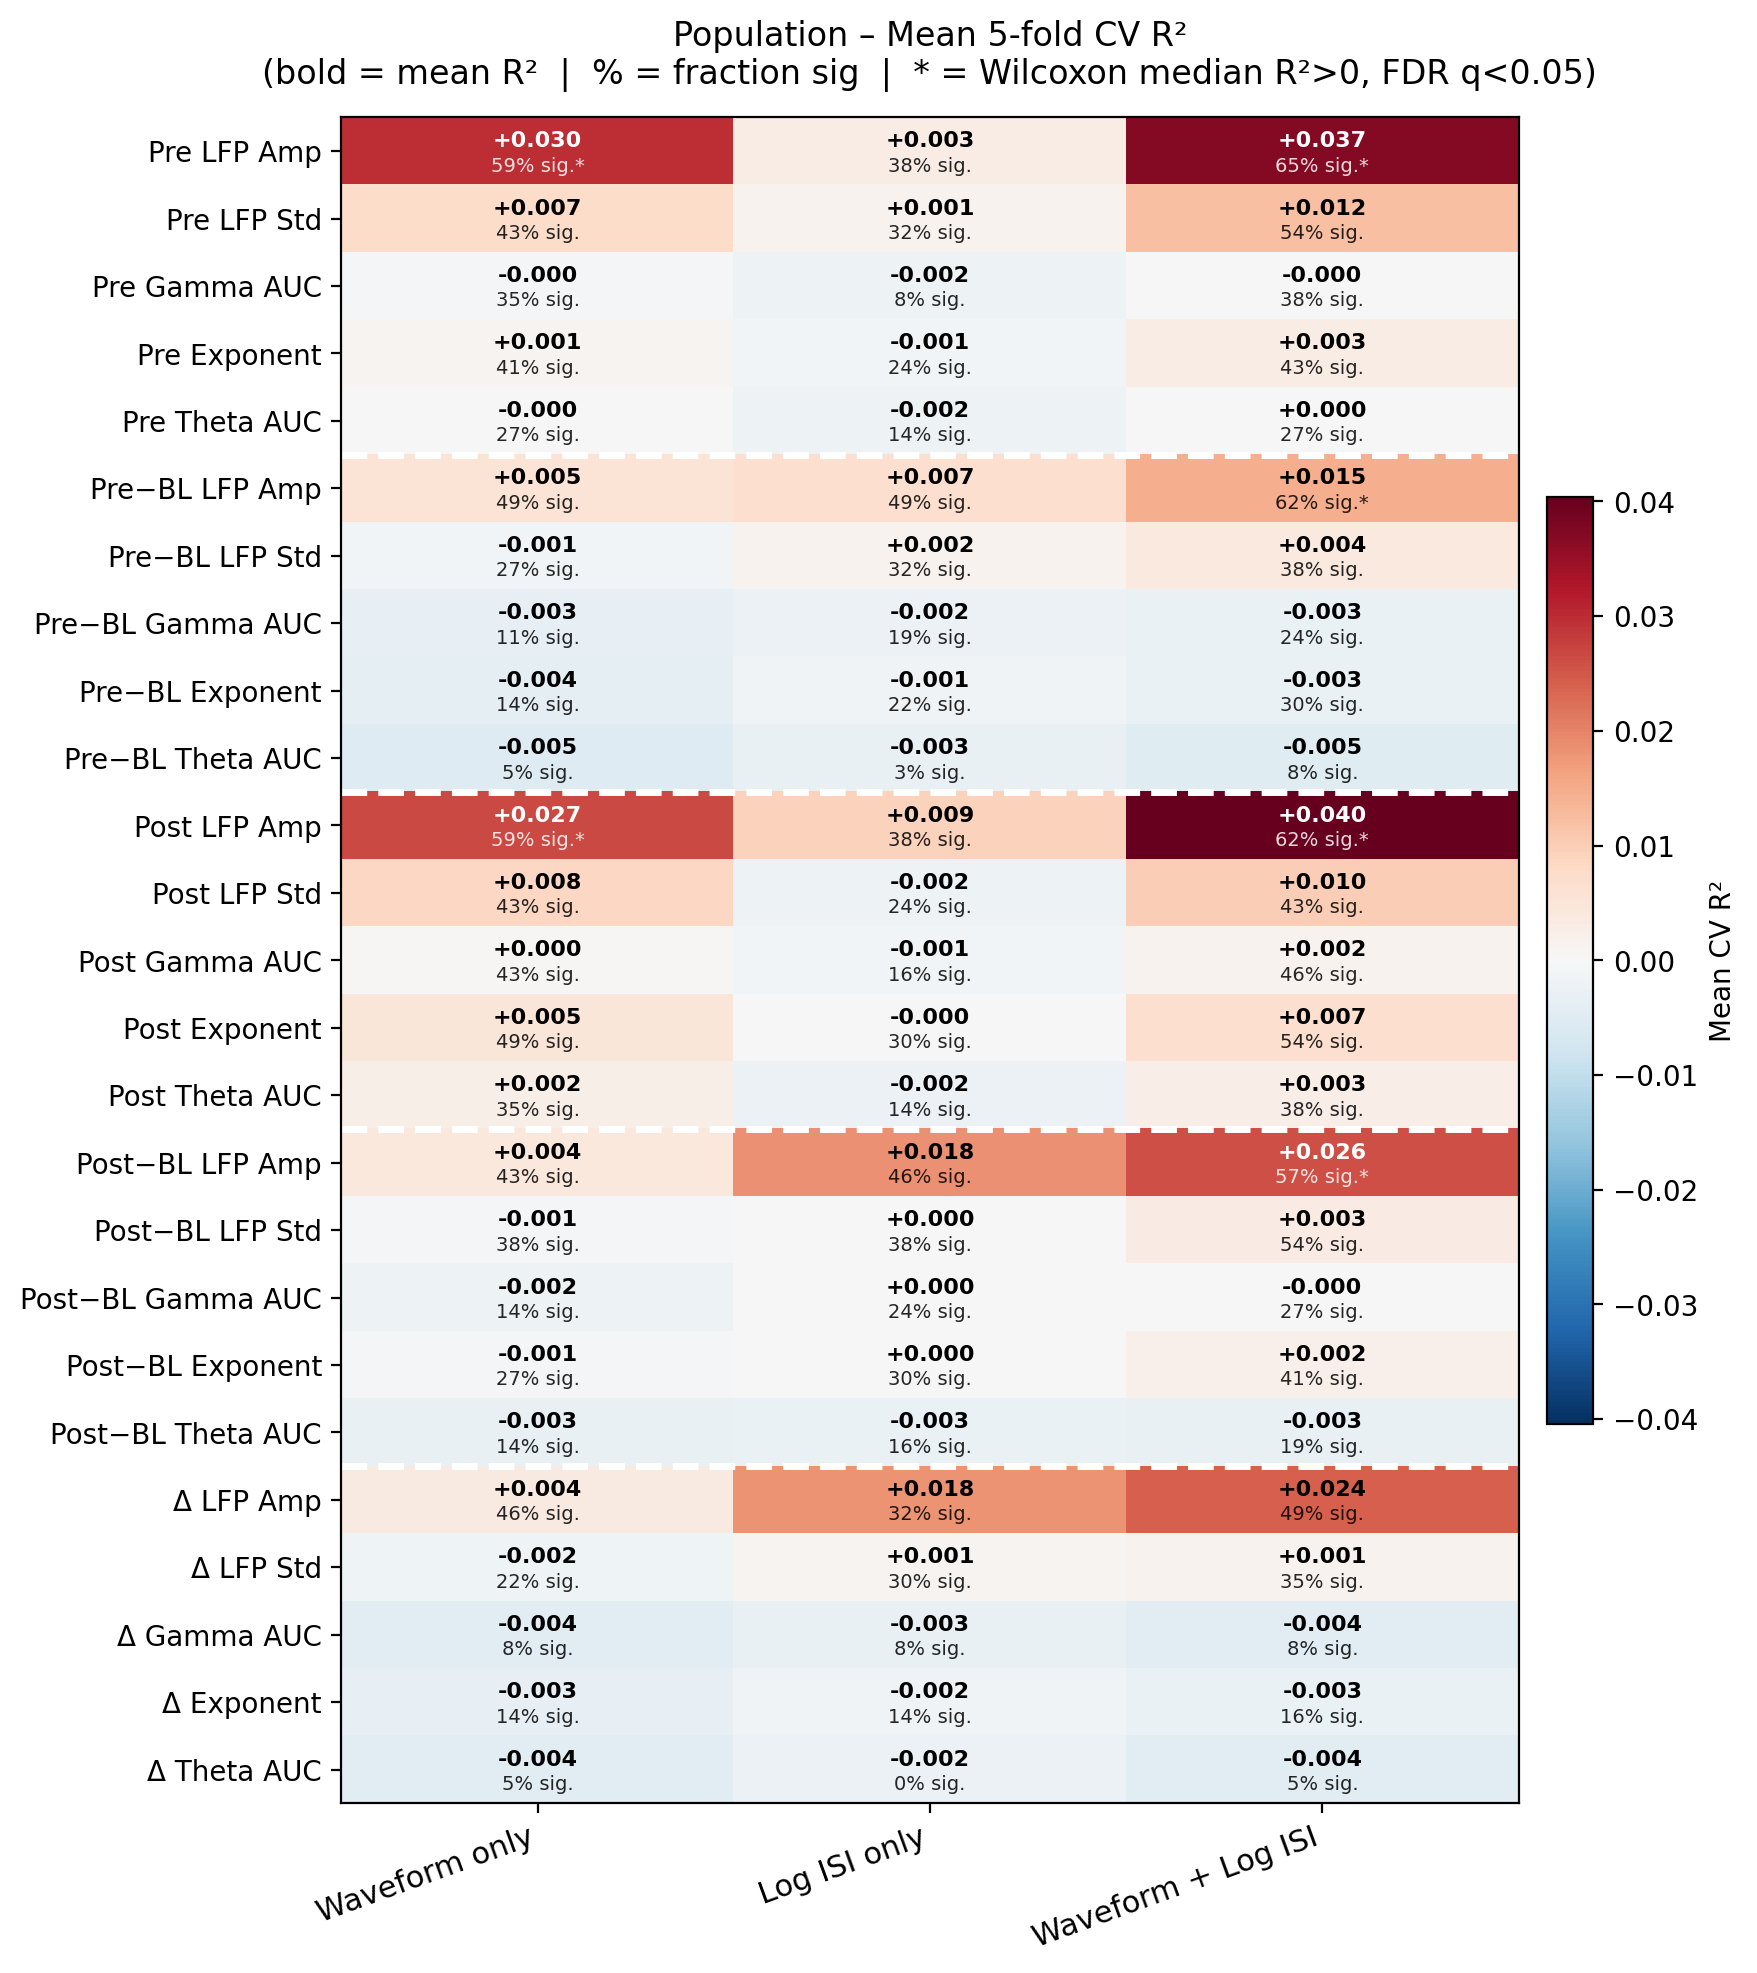

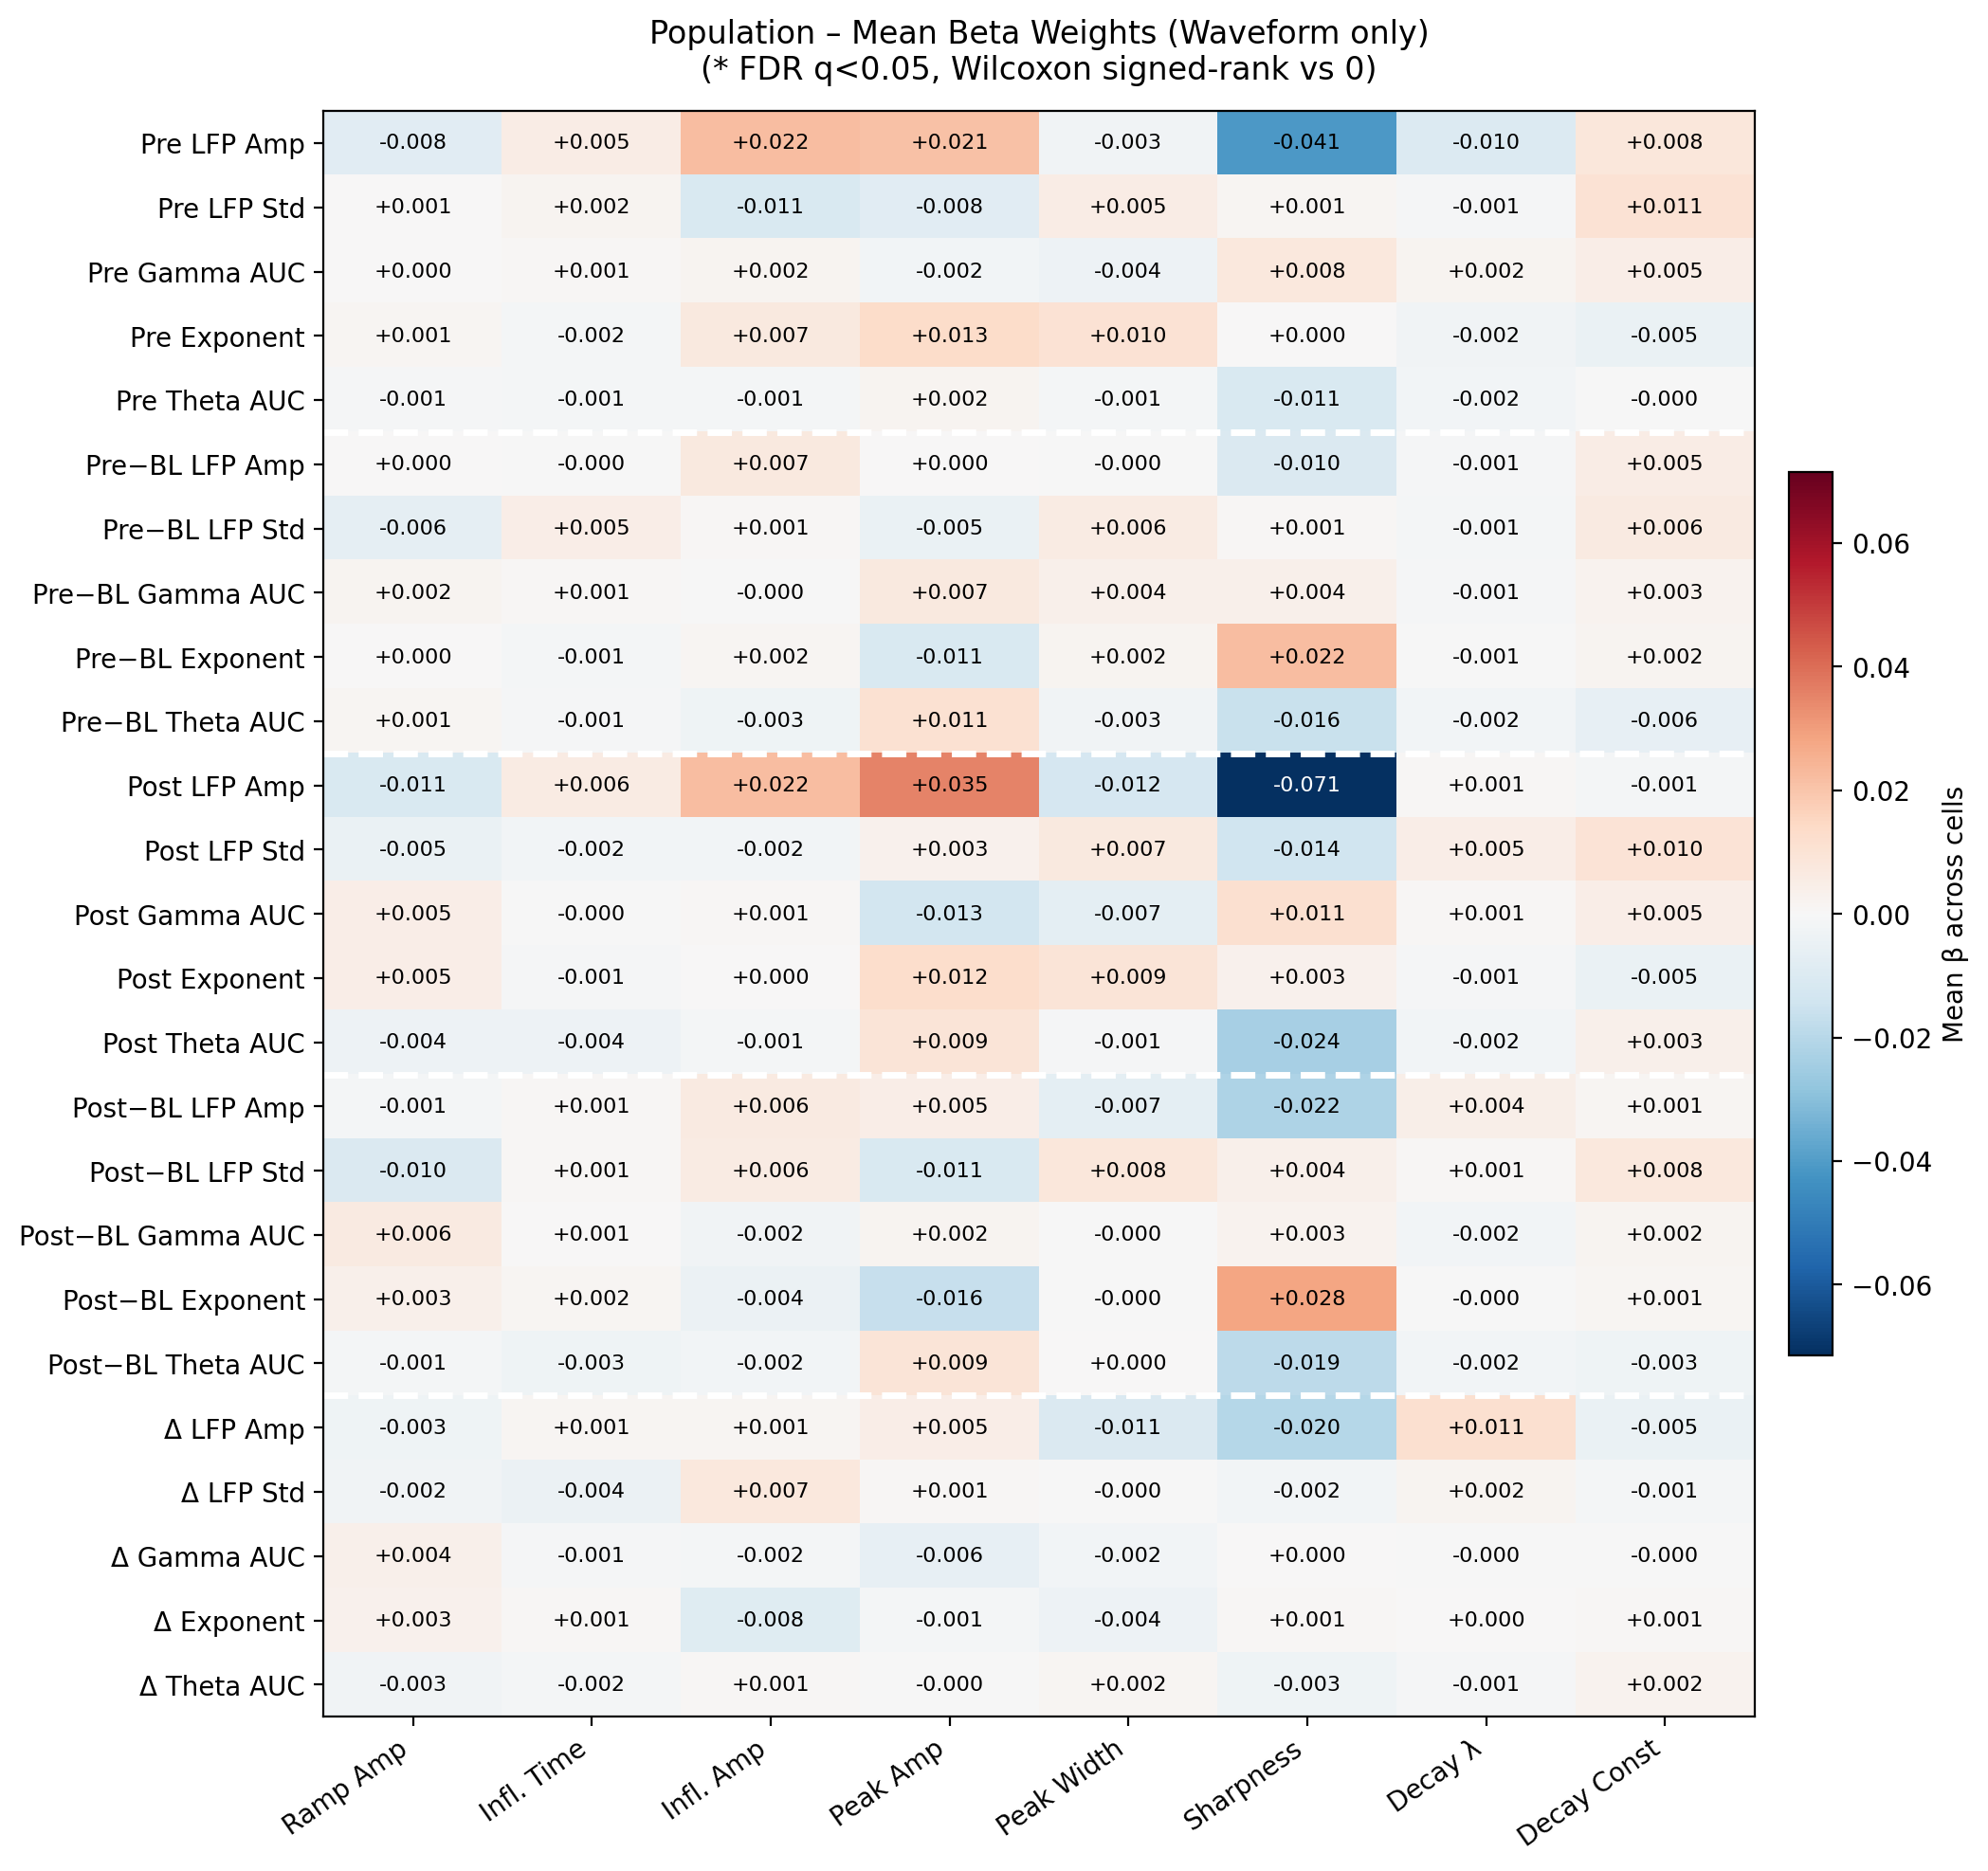

No population-level FDR-significant pairs.


In [7]:
# ── 4. Plots: R² heatmap, beta heatmap, rainclouds ────────────────────────────
mean_r2, frac_sig, mean_beta_mat, sig_beta_mat = plot_population_results(
    r2_pop, sig_pop, beta_pop, df_tests,
    target_names, target_labels, predictor_sets,
    df_frac=df_frac, df_r2=df_r2,
)

## 4. Visualisations

R² heatmap (targets × predictor sets), mean beta weight heatmap, per-cell R² distributions, and per-cell beta distributions. Stars on beta heatmap = significant Wilcoxon on that (target × feature) pair (p < 0.05, assessed within each target).

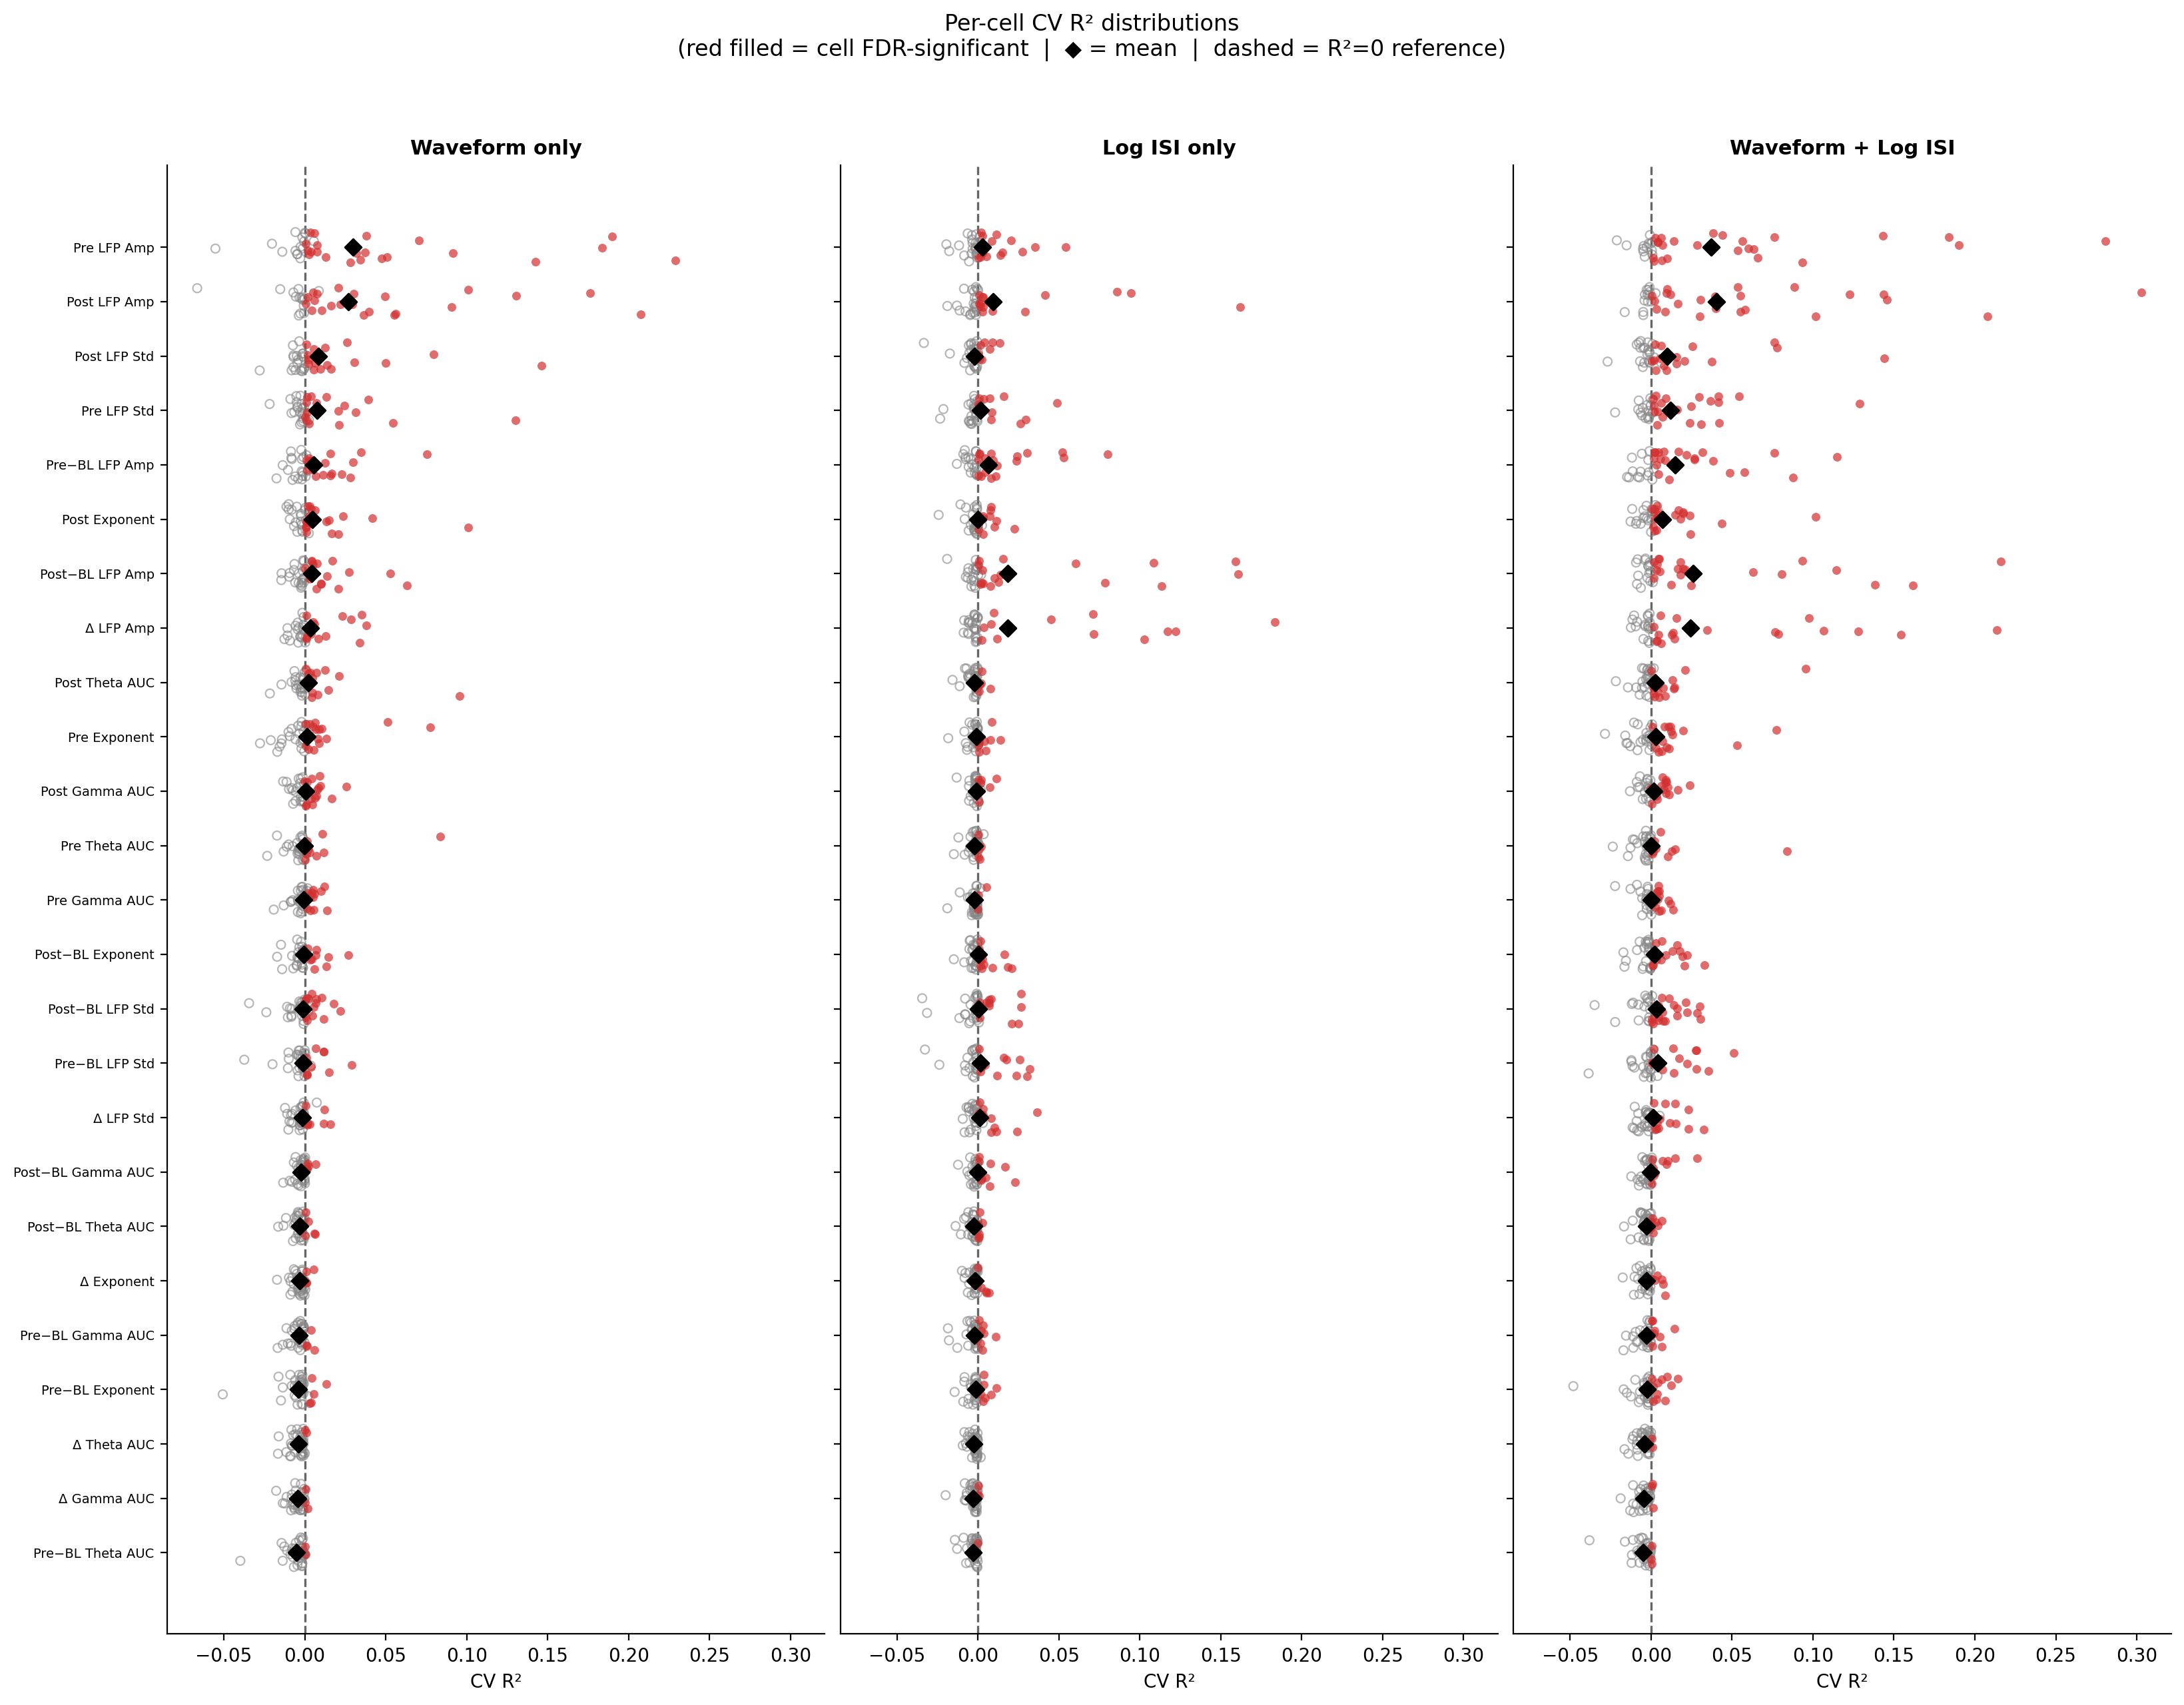

In [8]:
# ── 4b. R² distribution across cells ─────────────────────────────────────────
plot_r2_distributions(
    r2_pop, sig_pop, target_names, target_labels, predictor_sets,
    sort_by='Waveform only', min_r2_line=0.01,
)

In [ ]:
# ── 4c. Beta distributions across cells ──────────────────────────────────────
# One panel per waveform feature; targets sorted by mean R².
# Dot colour: red = that cell's model was significant (raw p < 0.05); grey = not.
# Median ◆: black = population Wilcoxon significant for that (target × feature) pair.
plot_beta_distributions(beta_pop, df_tests, target_names, target_labels,
                        sig_pop=sig_pop, sig_pset='Waveform only',
                        sort_by='mean_r2', r2_pop=r2_pop)

## 5. Actual vs predicted scatter (pooled)

Each point = one spike from one cell, z-scored within cell before pooling.
Only cells with significant Waveform-only models (raw p < 0.05) included. Each colour = one cell.

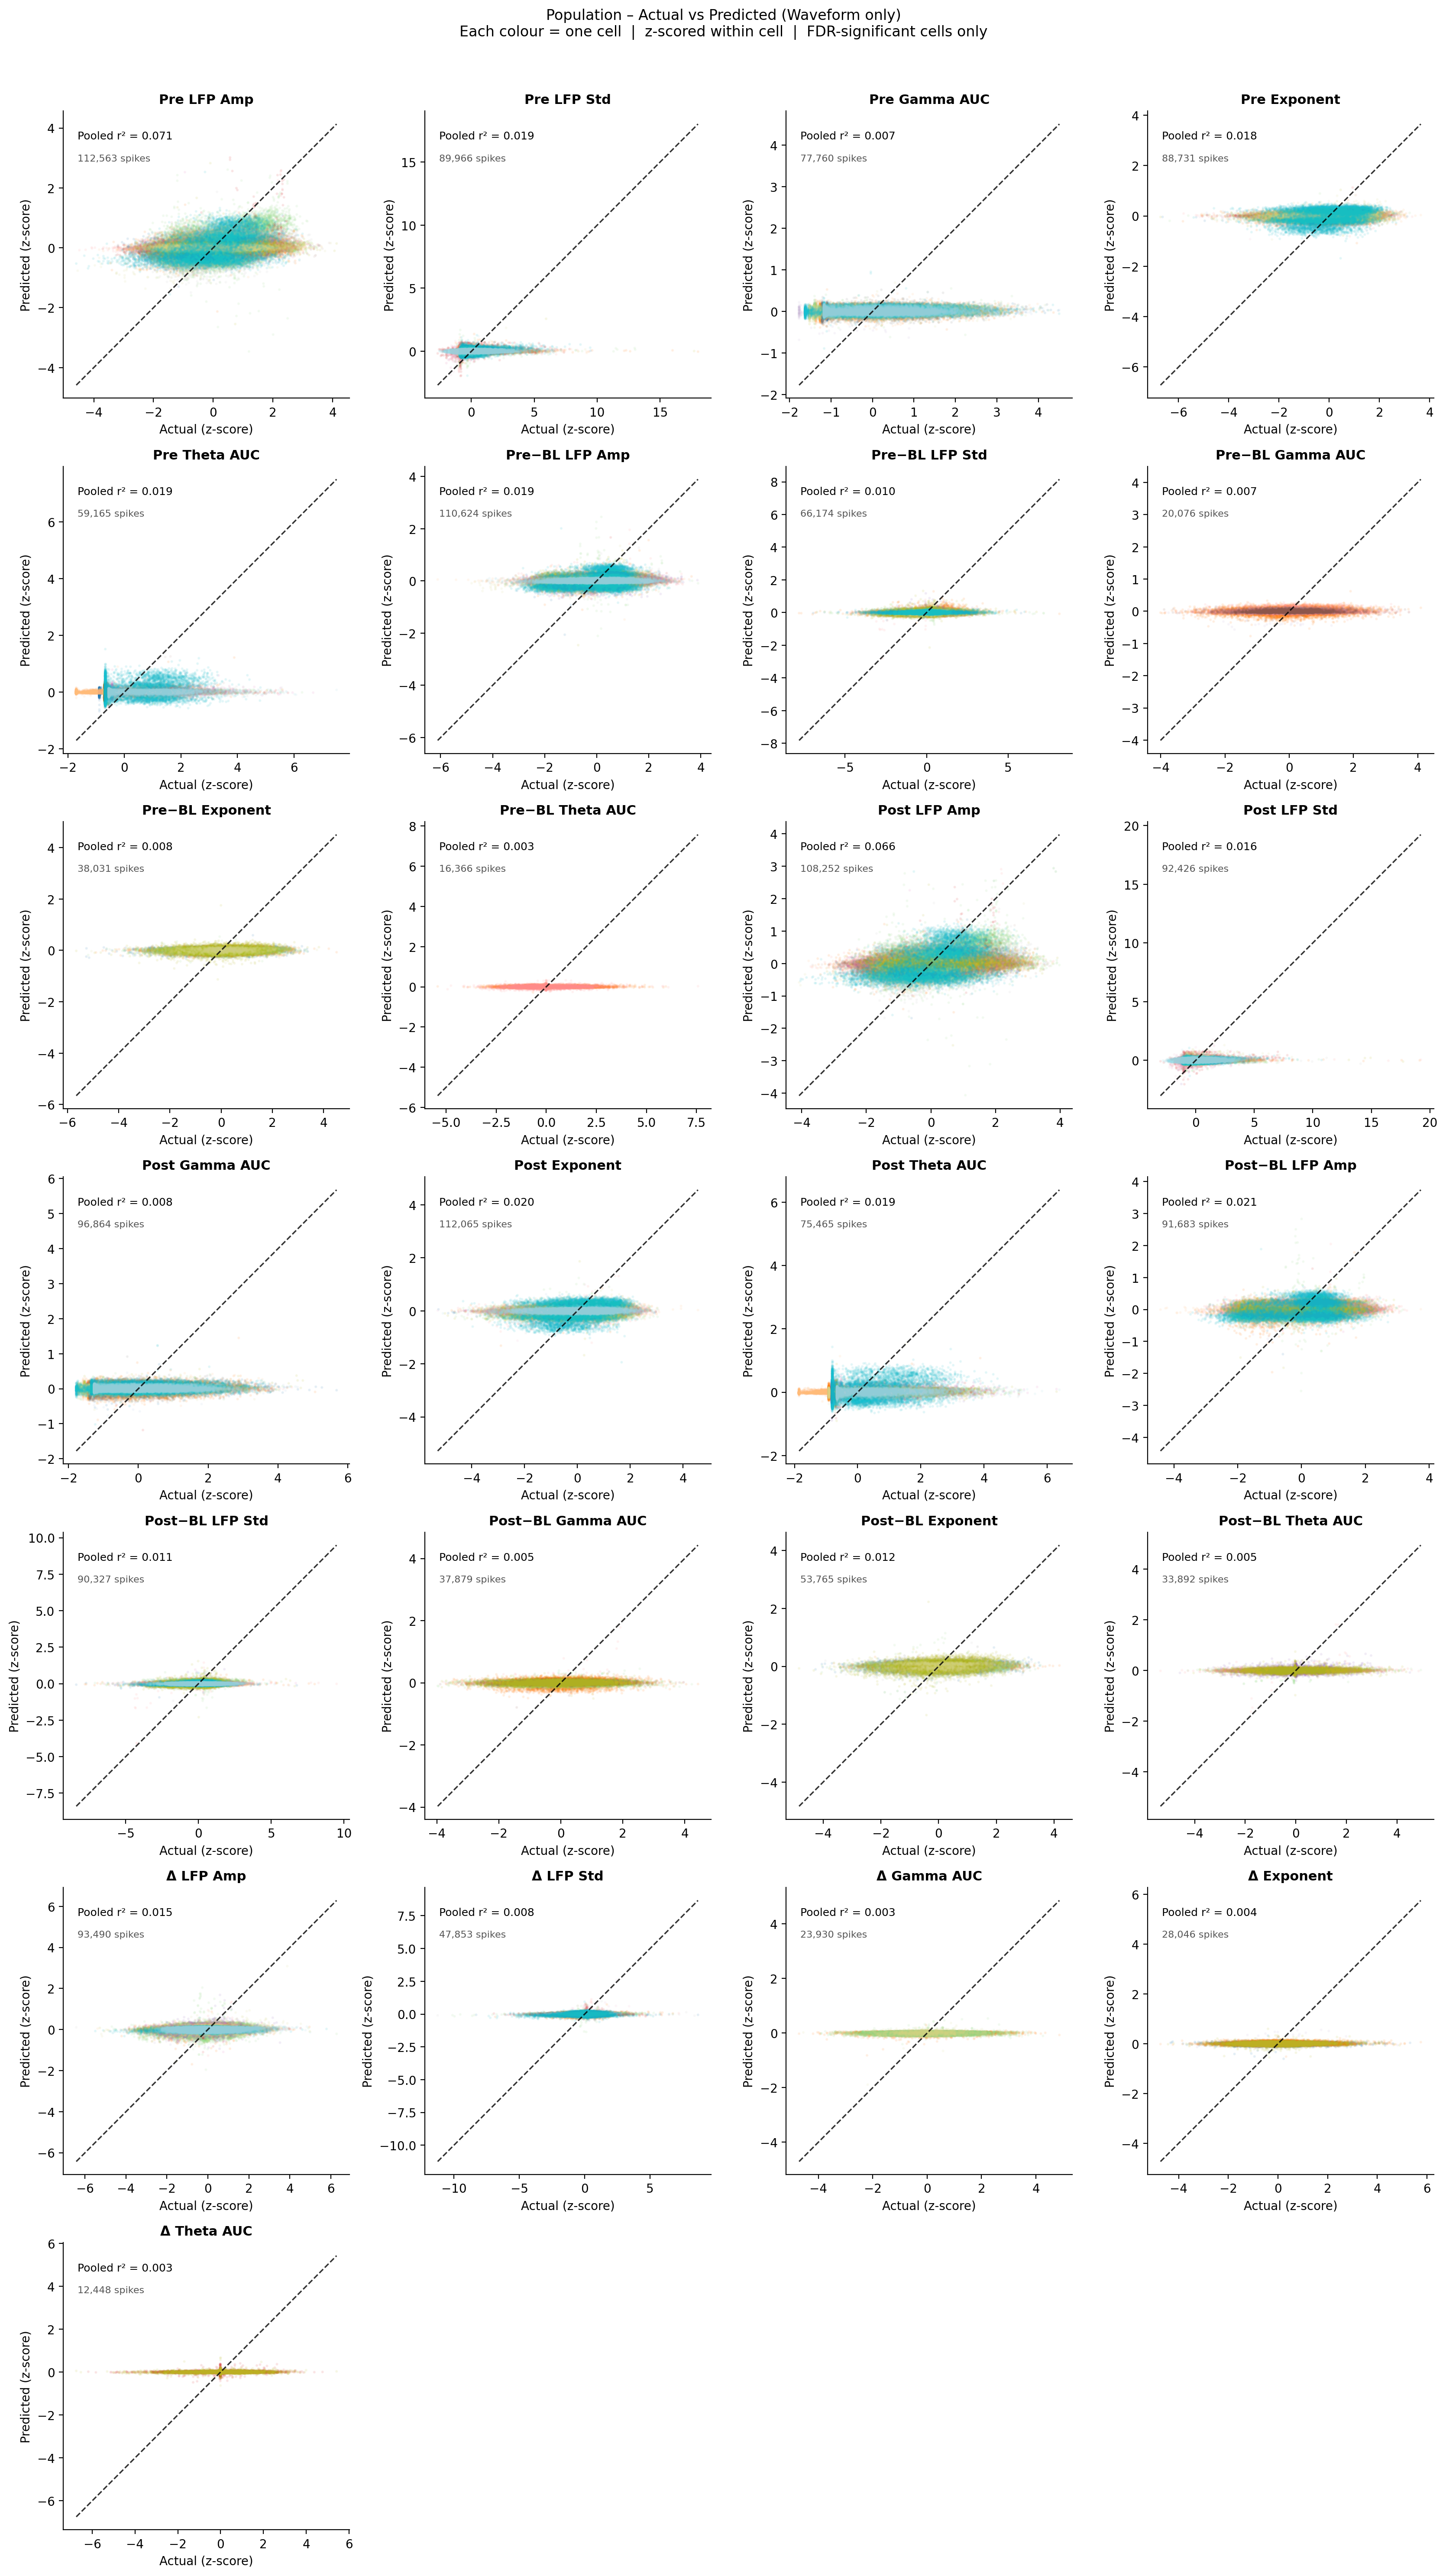

In [10]:
# ── 5. Population scatter (reads from pickles — fast) ────────────────────────
build_population_scatter(all_results, cell_ids, target_names, target_labels)

In [ ]:
# ── 6. Save ───────────────────────────────────────────────────────────────────
save_population_results(
    RIDGE_PICKLE_DIR, r2_pop, sig_pop, beta_pop, df_tests,
    mean_r2, frac_sig, mean_beta_mat, sig_beta_mat,
    target_names, target_labels, predictor_sets, cell_ids,
    df_frac=df_frac, df_r2=df_r2,
)

## 7. HPF vs no-HPF comparison

LFP amplitude and std targets were computed two ways:

- **No HPF**: raw LFP windows (acquisition bandpass 0.1–250 Hz), mean/std computed directly. Includes slow electrode drift (< 10 s timescale).
- **HPF 0.1 Hz**: same windows high-pass filtered at 0.1 Hz (4th-order zero-phase Butterworth) before computing mean/std. Removes slow drift, preserves network-state fluctuations.

All other targets (gamma AUC, exponent, theta AUC) are identical in both versions.

This comparison reveals whether the waveform → LFP relationship is driven by slow drift or genuine network-state coupling — if the signal survives HPF it is not pure drift.

In [ ]:
# ── 7. HPF vs no-HPF comparison ───────────────────────────────────────────────
hpf = compare_hpf_versions(
    RIDGE_PICKLE_DIR, cell_ids, target_names, target_labels,
    predictor_sets, min_cells=MIN_CELLS, alpha=ALPHA,
)

r2_hpf       = hpf['r2_hpf']
sig_hpf      = hpf['sig_hpf']
beta_hpf     = hpf['beta_hpf']
df_tests_hpf = hpf['df_tests_hpf']
res_hpf      = hpf['res_hpf']